# Safety Analysis Demo

Demonstrates the safety analysis module (`transduction.safety`), which checks
whether an FST admits finite decompositions for all target strings.

**Two levels of analysis:**
- **Level 1** (`compute_safe_states`): Individual-state safety via SCC analysis. Linear time, precomputable.
- **Level 2** (`compute_safe_powersets`): Powerset safety via lazy BFS + SCC. Exponential worst-case, but budgetable and gives an iff condition.

In [1]:
from transduction.fst import FST, EPSILON
from transduction.viz import visualize_automaton, display_table
from transduction.safety import (
    compute_safe_states,
    compute_safe_powersets,
    compute_frontier,
    _compute_finite_closure_states,
)
from transduction.universality import compute_ip_universal_states
from transduction import examples
from IPython.display import display, HTML

In [2]:
# Colors for safety visualization
SAFE_COLOR = '#90EE90'    # green
UNSAFE_COLOR = '#FF6B6B'  # red
UNIVERSAL_COLOR = '#87CEEB'  # blue (ip-universal subset of safe)
FINITE_COLOR = '#DDA0DD'  # plum (finite-closure subset of safe)

def show_safety(fst, title=None, detailed=False):
    """Visualize an FST with states colored by safety classification."""
    safe = compute_safe_states(fst)
    ip_universal = compute_ip_universal_states(fst)
    finite_closure = _compute_finite_closure_states(fst)

    def color(q):
        if q in ip_universal:
            return UNIVERSAL_COLOR
        elif q in finite_closure:
            return FINITE_COLOR
        elif q in safe:
            return SAFE_COLOR  # safe by induction (all successors safe)
        else:
            return UNSAFE_COLOR

    def label(q):
        tags = []
        if q in ip_universal:
            tags.append('U')
        if q in finite_closure:
            tags.append('F')
        if q in safe and q not in ip_universal and q not in finite_closure:
            tags.append('S')  # safe by induction
        if q not in safe:
            tags.append('!')
        tag = ','.join(tags)
        return f'{q} [{tag}]' if detailed else str(q)

    if title:
        display(HTML(f'<h3>{title}</h3>'))

    display(visualize_automaton(
        fst,
        fmt_state=label,
        sty_node=lambda q: {'style': 'filled,rounded', 'fillcolor': color(q)},
    ))

    n_safe = len(safe)
    n_total = len(fst.states)
    display(HTML(
        f'<b>{n_safe}/{n_total}</b> states safe &nbsp; '
        f'(<span style="color:{UNIVERSAL_COLOR}">ip-universal</span>={len(ip_universal)} &nbsp; '
        f'<span style="color:{FINITE_COLOR}">finite-closure</span>={len(finite_closure)} &nbsp; '
        f'<span style="color:{SAFE_COLOR}">inductive</span>={n_safe - len(ip_universal | finite_closure)} &nbsp; '
        f'<span style="color:{UNSAFE_COLOR}">unsafe</span>={n_total - n_safe})'
    ))

### Legend

| Color | Meaning |
|---|---|
| <span style="background:#87CEEB;padding:2px 8px">blue</span> | ip-universal (base case: accepts all inputs) |
| <span style="background:#DDA0DD;padding:2px 8px">plum</span> | finite closure (base case: no reachable cycle) |
| <span style="background:#90EE90;padding:2px 8px">green</span> | safe by induction (all successors are safe) |
| <span style="background:#FF6B6B;padding:2px 8px">red</span> | unsafe (can reach cycle among non-base-case states) |

---
## 1. Base cases

### 1.1 ip-universal: `delete_b`

Single state with self-loops on all input symbols. The state is ip-universal
(its input language is $\Sigma^*$), so it's a safe base case.

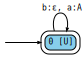

In [3]:
show_safety(examples.delete_b(), detailed=True)

### 1.2 Finite closure: linear chain

A chain `0 -a:x-> 1 -b:y-> 2` with no cycles. Every state has finite closure
(only finitely many strings can be read from it), so all are safe base cases.

In [4]:
fst = FST()
fst.add_start(0)
fst.add_arc(0, 'a', 'x', 1)
fst.add_arc(1, 'b', 'y', 2)
fst.add_stop(2)
show_safety(fst, 'Linear chain (finite closure)', detailed=True)

---
## 2. Inductive case

A state is **inductively safe** if it is not a base case itself, but all its
successors (via non-base-case transitions) eventually reach base cases without
forming a cycle.

### 2.1 Mixed: universal hub + finite tail

State 0 is ip-universal (self-loops on a,b). State 1 has only an `a` arc
to state 2, which has no outgoing arcs (finite closure). State 1 is safe
inductively: its only successor (state 2) is a base case.

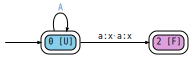

In [5]:
fst = FST()
fst.add_start(0)
fst.add_stop(0); fst.add_stop(2)
for x in ('a', 'b'):
    fst.add_arc(0, x, x, 0)
fst.add_arc(0, 'a', 'x', 1)
fst.add_arc(1, 'a', 'x', 2)
fst.states.add(1)
show_safety(fst, 'Universal hub + finite tail', detailed=True)

---
## 3. Unsafe states

### 3.1 Cycle with no base case

States 0 and 1 form a cycle (`0 -a:x-> 1 -b:y-> 0`). Neither is ip-universal
(each only accepts one input symbol), and neither has finite closure (they
can reach cycles). No base case is reachable, so both are **unsafe**.

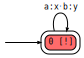

In [6]:
fst = FST()
fst.add_start(0); fst.add_stop(0)
fst.add_arc(0, 'a', 'x', 1)
fst.add_arc(1, 'b', 'y', 0)
fst.A.update({'a', 'b'})
show_safety(fst, 'Cycle with no base case', detailed=True)

### 3.2 Unsafe state reaching a cycle

State 0 branches: one path leads to an unsafe cycle (1 <-> 2), the other
to a safe ip-universal state (3). State 0 is unsafe because it can reach
the cycle among non-base-case states.

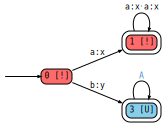

In [8]:
fst = FST()
fst.add_start(0); fst.add_stop(1); fst.add_stop(3)
fst.add_arc(0, 'a', 'x', 1)
fst.add_arc(1, 'a', 'x', 2)
fst.add_arc(2, 'a', 'x', 1)  # cycle
fst.add_arc(0, 'b', 'y', 3)
for x in ('a', 'b'):
    fst.add_arc(3, x, x, 3)  # ip-universal
show_safety(fst, 'Unsafe reaching cycle + safe branch', detailed=True)

---
## 4. Real examples from `transduction.examples`

### 4.1 `small()`: mixed safety

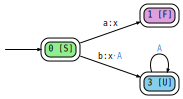

In [9]:
show_safety(examples.small(), 'examples.small()', detailed=True)

### 4.2 `triplets_of_doom()`: all unsafe

Each state only handles one input symbol. All states are in cycles,
none are ip-universal or have finite closure. Every state is unsafe.

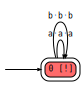

In [10]:
show_safety(examples.triplets_of_doom(), 'examples.triplets_of_doom()', detailed=True)

### 4.3 `bpe_like()`: all safe

BPE-style trie transducer. Every state is ip-universal (has arcs on all
input symbols), so all are safe base cases.

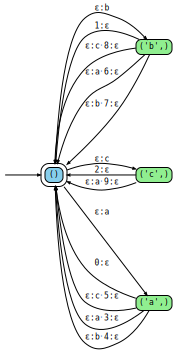

In [11]:
fst = examples.bpe_like(vocab_size=10, alphabet=('a', 'b', 'c'), max_len=3)
show_safety(fst, f'examples.bpe_like() ({len(fst.states)} states)')

### 4.4 `newspeak2()`: pattern replacement

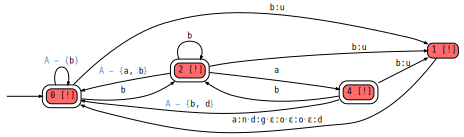

In [12]:
show_safety(examples.newspeak2(), 'examples.newspeak2()', detailed=True)

---
## 5. Level 2: Powerset safety (collective universality)

Level 1 checks individual states. But some transducers have states that
are individually unsafe yet *collectively* safe as a set. Level 2 operates
on **powerstates** (sets of states).

### 5.1 Collectively universal example

State 1 only handles input `a`; state 2 only handles `b`. Neither alone
is ip-universal. But **{1, 2}** is collectively ip-universal: together they
cover all inputs, and every successor powerstate is again {1, 2}.

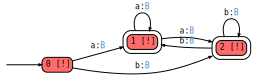

In [13]:
fst = FST()
fst.add_start(0); fst.add_stop(1); fst.add_stop(2)
fst.add_arc(0, 'a', 'x', 1)
fst.add_arc(0, 'b', 'x', 2)
# State 1: handles 'a', successors go to {1, 2}
fst.add_arc(1, 'a', 'x', 1)
fst.add_arc(1, 'a', 'x', 2)
# State 2: handles 'b', successors go to {1, 2}
fst.add_arc(2, 'b', 'x', 1)
fst.add_arc(2, 'b', 'x', 2)

display(HTML('<h3>Collectively universal: Level 1 vs Level 2</h3>'))
show_safety(fst, 'Level 1: individual states', detailed=True)

In [14]:
# Level 1: states 1, 2 are individually unsafe
safe_individual = compute_safe_states(fst)
print(f'Level 1 safe states: {safe_individual}')
print(f'  State 1 safe? {1 in safe_individual}')
print(f'  State 2 safe? {2 in safe_individual}')

# Level 2: powerstate {1, 2} is collectively safe
safe_ps = compute_safe_powersets(fst, [frozenset({1, 2})])
print(f'\nLevel 2 safe powersets: {safe_ps}')
print(f'  {{1, 2}} safe? {frozenset({1, 2}) in safe_ps}')

Level 1 safe states: frozenset()
  State 1 safe? False
  State 2 safe? False

Level 2 safe powersets: {frozenset({1, 2})}
  {1, 2} safe? True


### 5.2 `triplets_of_doom()`: unsafe even at Level 2

From {0}, input `a` leads to {1}, but {1} has no `b` arcs.
The powerset analysis also finds this unsafe.

In [15]:
fst = examples.triplets_of_doom()
safe_ps = compute_safe_powersets(fst, [frozenset({0})])
print(f'triplets_of_doom: {{0}} safe at Level 2? {frozenset({0}) in safe_ps}')
print(f'Safe powersets: {safe_ps if safe_ps else "(none)"}')

triplets_of_doom: {0} safe at Level 2? False
Safe powersets: (none)


---
## 6. Frontier computation

`compute_frontier(fst, target)` computes $F(t)$: the set of states reachable
from initial states along arcs whose output labels concatenate to `target`.
This is the set of states the transducer could be in after emitting `target`.

In [16]:
fst = examples.small()
safe = compute_safe_states(fst)
ip_universal = compute_ip_universal_states(fst)

targets = [(), ('x',), ('x', 'a')]

rows = []
for t in targets:
    frontier = compute_frontier(fst, t)
    t_str = ''.join(t) if t else 'epsilon'
    all_safe = frontier <= safe
    status = 'all safe' if all_safe else 'has unsafe'
    rows.append([t_str, frontier, status])

display(HTML('<h3>Frontiers for examples.small()</h3>'))
display_table(rows, headings=['Target t', 'Frontier F(t)', 'Safety'])

Target t,Frontier F(t),Safety
epsilon,frozenset({0}),all safe
x,"frozenset({1, 2})",all safe
xa,frozenset({3}),all safe


---
## 7. Putting it together: end-to-end safety check

To check whether a transducer admits finite decompositions for all targets:
1. Compute safe states (Level 1)
2. If all start states are safe, we're done
3. Otherwise, try Level 2 on the start powerstate

In [17]:
def check_safety(fst, name=''):
    """End-to-end safety check with both levels."""
    prefix = f'{name}: ' if name else ''

    safe = compute_safe_states(fst)
    start_ps = frozenset(fst.start)
    n_safe = len(safe)
    n_total = len(fst.states)

    # Level 1: are all start states individually safe?
    if start_ps <= safe:
        print(f'{prefix}Level 1 PASS ({n_safe}/{n_total} states safe). '
              f'All start states are individually safe.')
        return True

    print(f'{prefix}Level 1 FAIL ({n_safe}/{n_total} states safe). '
          f'Trying Level 2...')

    # Level 2: is the start powerstate collectively safe?
    safe_ps = compute_safe_powersets(fst, [start_ps], budget=1000)
    if start_ps in safe_ps:
        print(f'{prefix}Level 2 PASS. Start powerstate {set(start_ps)} '
              f'is collectively safe.')
        return True

    print(f'{prefix}Level 2 FAIL. Start powerstate {set(start_ps)} '
          f'is NOT safe (may have infinite decompositions).')
    return False


test_cases = [
    ('delete_b', examples.delete_b()),
    ('small', examples.small()),
    ('newspeak2', examples.newspeak2()),
    ('bpe_like', examples.bpe_like(vocab_size=10, alphabet=('a', 'b', 'c'), max_len=3)),
    ('triplets_of_doom', examples.triplets_of_doom()),
]

for name, fst in test_cases:
    check_safety(fst, name)
    print()

delete_b: Level 1 PASS (1/1 states safe). All start states are individually safe.

small: Level 1 PASS (4/4 states safe). All start states are individually safe.

newspeak2: Level 1 FAIL (0/8 states safe). Trying Level 2...
newspeak2: Level 2 FAIL. Start powerstate {0} is NOT safe (may have infinite decompositions).

bpe_like: Level 1 PASS (11/11 states safe). All start states are individually safe.

triplets_of_doom: Level 1 FAIL (0/5 states safe). Trying Level 2...
triplets_of_doom: Level 2 FAIL. Start powerstate {0} is NOT safe (may have infinite decompositions).



---
## 8. Budget control (Level 2)

The powerset analysis is exponential in the worst case ($2^{|S|}$ powerstates).
The `budget` parameter caps exploration. Smaller budgets are faster but may
miss safe powerstates (sound but incomplete). At budget $\geq 2^{|S|}$,
the analysis is complete (iff).

In [18]:
fst = examples.bpe_like(vocab_size=10, alphabet=('a', 'b', 'c'), max_len=3)
start_ps = frozenset(fst.start)

for budget in [1, 5, 10, 50, 100]:
    safe_ps = compute_safe_powersets(fst, [start_ps], budget=budget)
    verdict = 'safe' if start_ps in safe_ps else 'inconclusive'
    print(f'budget={budget:>4d}  |  certified={len(safe_ps):>3d} powersets  |  start: {verdict}')

budget=   1  |  certified=  1 powersets  |  start: safe
budget=   5  |  certified=  1 powersets  |  start: safe
budget=  10  |  certified=  1 powersets  |  start: safe
budget=  50  |  certified=  1 powersets  |  start: safe
budget= 100  |  certified=  1 powersets  |  start: safe
